In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pymc as pm
import pandas as pd
import numpy as np

In [3]:
import plotly.graph_objects as go

In [4]:
# test data

# --- Config ---
GRID = 30          # 100x100 grid
MASK_SIZE = 10      # 50x50 mask in the center
T = 10              # timesteps
sigma = 3.0


N = GRID * GRID     # 10000 cells

# --- Mask (center 50x50) ---
mask = np.zeros((GRID, GRID), dtype=bool)
start = (GRID - MASK_SIZE) // 2  # 25
mask[start:start+MASK_SIZE, :MASK_SIZE] = True
mask_flat = mask.flatten()  # shape (10000,)

# --- Generate density moving bottom -> top ---
# Use a Gaussian blob that travels from row ~90 to row ~10 over T steps
rng = np.random.default_rng(42)

Y = np.zeros((T, N))
Z = np.zeros((T, N), dtype=int)

for t in range(T):
    # Blob center: moves from bottom (row 90) to top (row 10)
    row_center = 0.9*GRID - t * (0.8*GRID / (T - 1))  # 90 -> 10
    col_center = GRID / 2                  # stays centered horizontally

    # Build 2D Gaussian
    rows = np.arange(GRID)
    cols = np.arange(GRID)
    rr, cc = np.meshgrid(rows, cols, indexing='ij')

    dist_sq = (rr - row_center)**2 + (cc - col_center)**2
    density = density = np.exp(-dist_sq / (2 * sigma**2))
    # Zero out points beyond 2 sigma (distance > 2*sigma)
    density[dist_sq > (4 * sigma)**2] = 0


    # Add a bit of noise so it's not perfectly clean
    # noise = rng.uniform(0, 0.05, size=(GRID, GRID))
    # density += noise

    # Zero out masked cells
    density[mask] = 0.0

    # Normalize to sum = 1
    total = density.sum()
    density /= total

    Y[t] = density.flatten()
    Z[t] = (Y[t] > 0).astype(int)

q = 1 - mask_flat.astype(int)

# --- Sanity checks ---
assert Y.shape == (T, N)
assert Z.shape == (T, N)
assert np.allclose(Y.sum(axis=1), 1.0), "Each y_t must sum to 1"
assert np.all(Y[:, mask_flat] == 0), "Masked cells must be 0"
assert np.array_equal(Z, (Y > 0).astype(int))

print(f"Y shape: {Y.shape}")
print(f"Z shape: {Z.shape}")
print(f"y_t sums: {Y.sum(axis=1)}")
print(f"Non-zero cells per t: {Z.sum(axis=1)}")
print(f"Masked cells always 0: {np.all(Y[:, mask_flat] == 0)}")

# --- Save ---
# np.save("Y.npy", Y)
# np.save("Z.npy", Z)
# np.save("mask_flat.npy", mask_flat)

Y shape: (10, 900)
Z shape: (10, 900)
y_t sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Non-zero cells per t: [273 323 362 381 392 391 386 373 338 292]
Masked cells always 0: True


In [5]:
def view_matrix(M: np.ndarray, title: str = ""):
    """
    M: array of shape (T, N) where N = GRID*GRID
    """
    T, N = M.shape
    GRID = int(np.sqrt(N))
    assert GRID * GRID == N, "N must be a perfect square"

    frames = [
        go.Frame(
            data=go.Heatmap(z=M[t].reshape(GRID, GRID), colorscale="plasma"),
            name=str(t),
        )
        for t in range(T)
    ]

    fig = go.Figure(
        data=go.Heatmap(z=M[0].reshape(GRID, GRID), colorscale="plasma",
                        zmin=M.min(), zmax=M.max()),
        frames=frames,
    )

    fig.update_layout(
        title=title,
        width=700,
        height=700,
        sliders=[{
            "active": 0,
            "steps": [{"args": [[str(t)], {"frame": {"duration": 0}, "mode": "immediate"}],
                        "label": str(t), "method": "animate"} for t in range(T)],
            "x": 0.1, "len": 0.8,
            "currentvalue": {"prefix": "t = "},
        }],
    )

    return fig

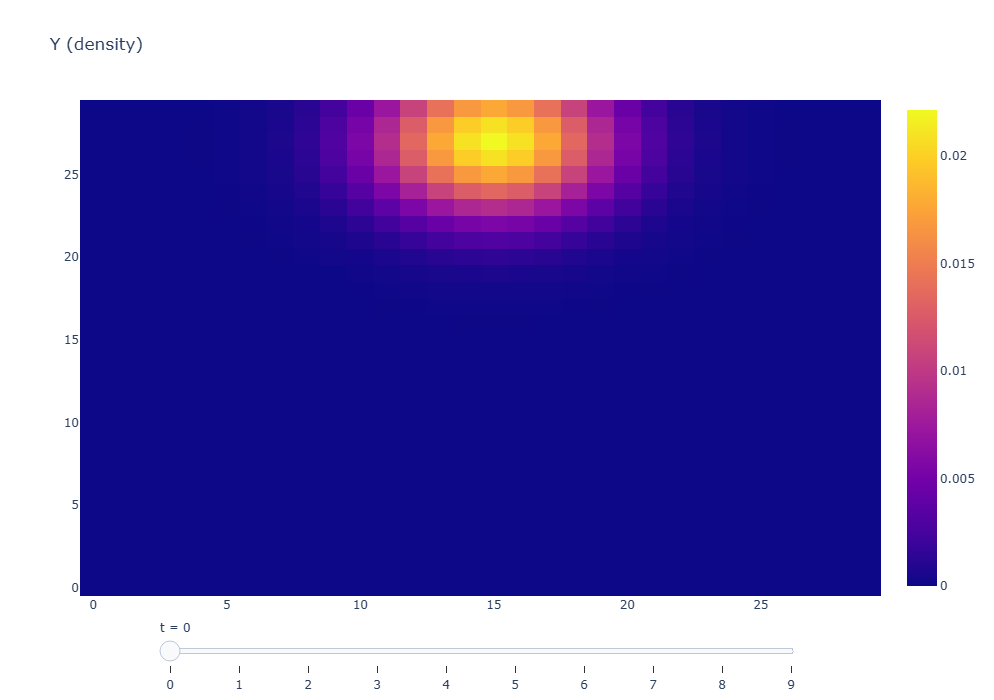

In [6]:
view_matrix(Y, title="Y (density)").show()

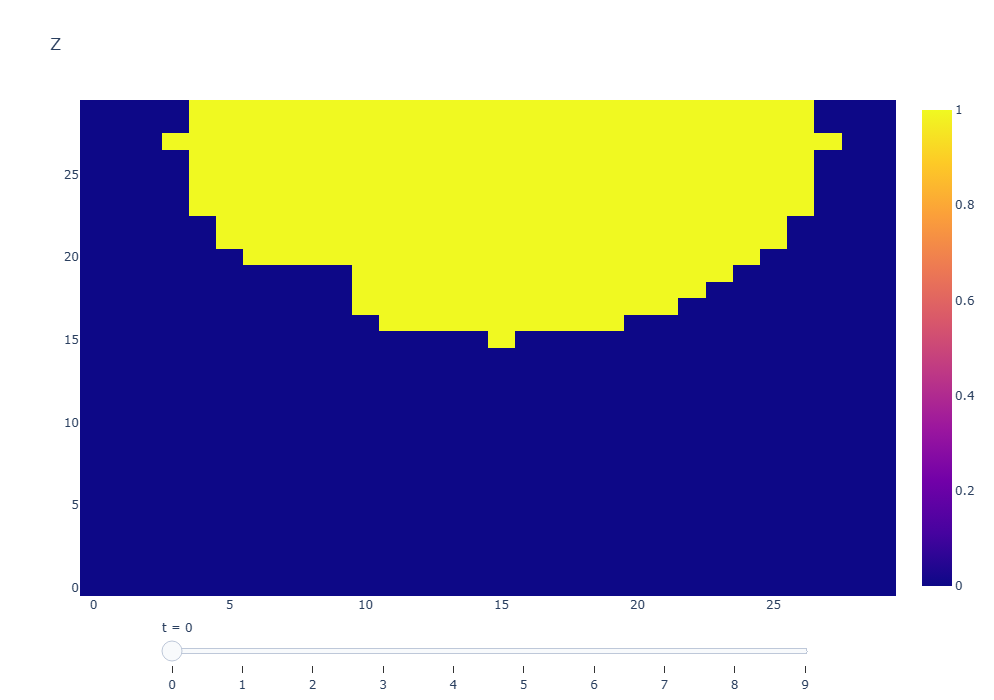

In [7]:
view_matrix(Z, title="Z").show()

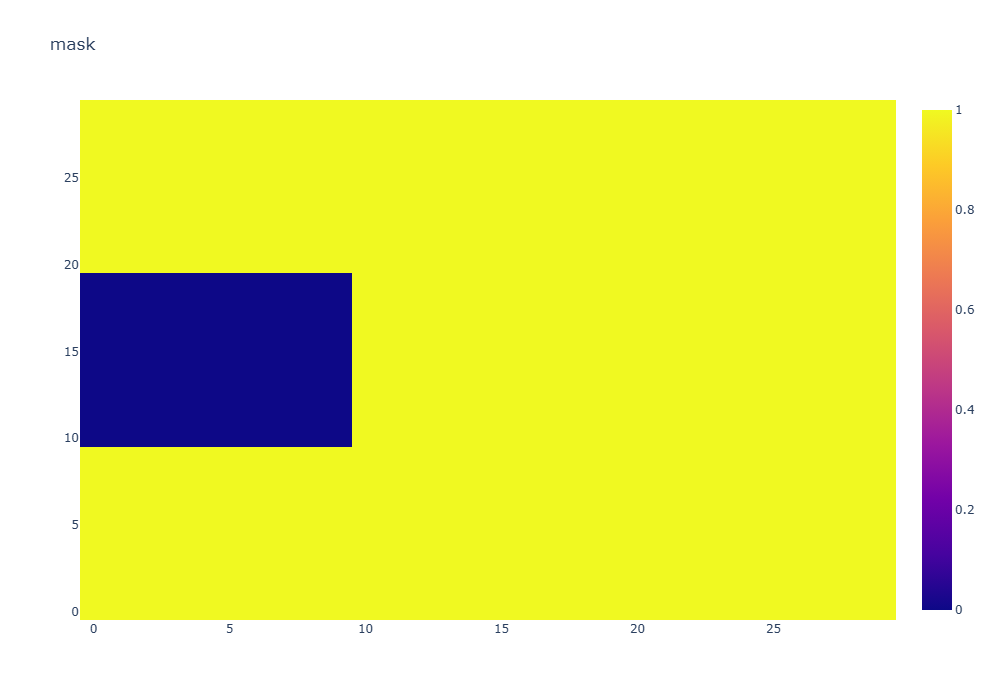

In [8]:
view_matrix(q[np.newaxis, :], title="mask").show()

In [17]:
from mcmc import LogLikelihood

In [121]:
w = 2750

In [122]:
X = np.full((10, 900), 1/900)

In [123]:
q[np.newaxis, :].shape

(1, 900)

In [124]:
P = 1 - q[np.newaxis, :] * (1 - (1 - X) ** w)

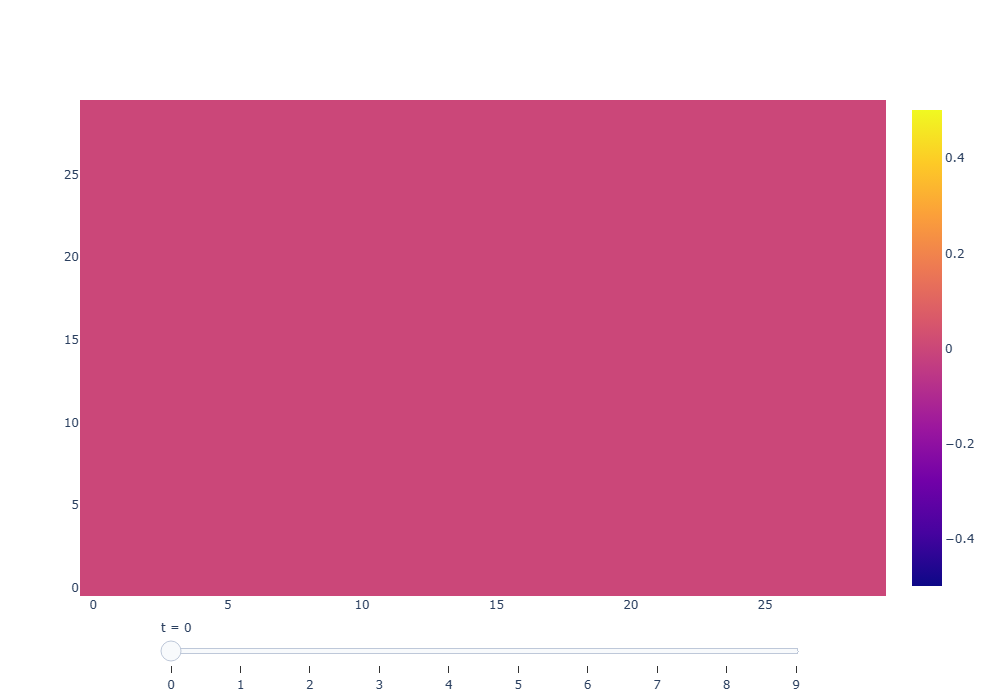

In [125]:
view_matrix(X)

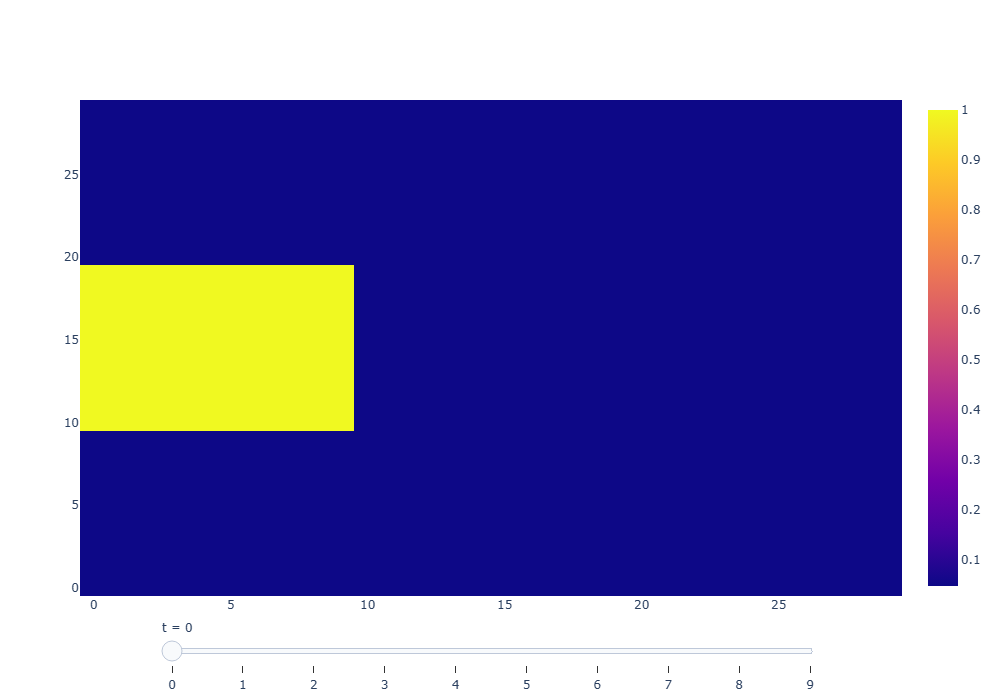

In [126]:
view_matrix(P)

In [127]:
LogLikelihood(Y[5], Z[5], X[5], P[5], w)

1.0
-1250.4170270635607
-1269.246728499766
-1269.246728499766
5998.813421532805
5707.511350116047


np.float64(-633.0521622331107)

In [52]:
# doesn't work with big w
# random walk. used in covid
# w = 1000 last step is too big. wait how?? ah deg is < 1
# w = 10000 gamma is too big

In [124]:
from scipy.spatial.distance import cdist
from scipy.stats import uniform

In [125]:
# костыли
coords = np.stack([rr.flatten(), cc.flatten()], axis=1)  # (N, 2)
D = cdist(coords, coords)  # (N, N)
angles = (np.arctan2(coords[None,:,0] - coords[:,None,0], 
                    coords[None,:,1] - coords[:,None,1]) + 2 * np.pi) % (2 * np.pi)   # (N, N)
phi_density = uniform.pdf(angles, loc=np.pi-0.1, scale=0.2)  # (N, N)

In [126]:
# maybe make a class later

In [128]:
with pm.Model() as dummy_model:
    phi = pm.Uniform('phi', lower=np.pi-0.1, upper=np.pi+0.1)
    mu_g = pm.LogNormal('mu_g', mu=np.log(150), sigma=1)
    sigma_g = pm.LogNormal('sigma_g', mu=np.log(50), sigma=0.5)
    # fix alpha
    # mean in 0.003
    # \Sigma
    # sigmoid
    Alpha = pm.Normal('Alpha', mu, )

    # gamma 
    P_g = np.einsum('ti,ij->tij', Alpha, np.eye(Alpha.shape[-1])) + D

    # something + softmax. norm
    x_0 = pm.Normal('x_0', mu=Y[0])
    
    phi_logp =  /// (phi, angles)
    # there's also conditional logp

    logP_theta = np.log(P_g) + /// (mu_g)[np.newaxis, :] + /// (sigma_g)[np.newaxis, :]
    # how do i get probability of the sampled value

    logA = np.log(P_g) + phi_logp[np.newaxis, :] + logP_theta
    X = np.exp(np.cumsum(logA, axis=0)) * x_0

    # LIkelihood
    # shouldnt likelihood be for the whole series
    # actually how does dirichlet shows likelihood exactly

SyntaxError: invalid syntax (666828926.py, line 14)